# Initial EDA — BTC & ETH Price Data

Notebook ini digunakan untuk eksplorasi data awal dari CoinGecko API sebagai bagian dari branch `feat/initial-eda`.

Tujuan EDA:
1. Melihat bentuk & rentang data harga BTC dan ETH.
2. Mengecek missing value.
3. Melihat tren harga dan volume dari waktu ke waktu.
4. Menghitung statistik dasar volatilitas sebagai bahan kalibrasi threshold label (Naik/Turun/Stabil).

In [4]:
import os
import sys

# Cari folder root project secara otomatis (folder yang punya subfolder 'src'),
# supaya import tidak bergantung pada working directory Jupyter saat ini.
project_root = os.getcwd()
while not os.path.isdir(os.path.join(project_root, 'src')):
    parent = os.path.dirname(project_root)
    if parent == project_root:
        raise RuntimeError("Folder 'src' tidak ditemukan. Pastikan notebook ada di dalam project PredictaCoin.")
    project_root = parent

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Project root terdeteksi: {project_root}')

import pandas as pd
import matplotlib.pyplot as plt

from src.data.fetch_coingecko import fetch_historical_as_dataframe, save_raw_data

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

Project root terdeteksi: /workspaces/PredictaCoin


## 1. Ambil data dari CoinGecko API

In [5]:
df_btc = fetch_historical_as_dataframe('bitcoin', days=7)
df_eth = fetch_historical_as_dataframe('ethereum', days=7)

raw_dir = os.path.join(project_root, 'data', 'raw')
save_raw_data(df_btc, 'bitcoin', out_dir=raw_dir)
save_raw_data(df_eth, 'ethereum', out_dir=raw_dir)

df_btc.head()

Data disimpan ke: /workspaces/PredictaCoin/data/raw/bitcoin_20260912_0740.csv
Data disimpan ke: /workspaces/PredictaCoin/data/raw/ethereum_20260912_0740.csv


,timestamp,coin_id,price,volume,market_cap
0,2026-09-05 08:00:00,bitcoin,"79,711.97","31,406,429,050.79","1,600,592,617,525.49"
1,2026-09-05 09:00:00,bitcoin,"79,647.88","30,591,484,918.16","1,599,323,178,465.32"
2,2026-09-05 10:00:00,bitcoin,"79,627.00","29,123,452,958.85","1,598,903,862,394.46"
3,2026-09-05 11:00:00,bitcoin,"79,624.22","28,537,781,488.37","1,598,848,118,705.79"
4,2026-09-05 12:00:00,bitcoin,"79,616.73","27,766,608,200.77","1,598,697,624,307.53"


## 2. Info umum & cek missing value

In [6]:
print('=== BTC ===')
print(df_btc.info())
print('\nMissing value per kolom:')
print(df_btc.isnull().sum())

print('\n=== ETH ===')
print(df_eth.info())
print('\nMissing value per kolom:')
print(df_eth.isnull().sum())

=== BTC ===
<class 'pandas.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   169 non-null    datetime64[ms]
 1   coin_id     169 non-null    str           
 2   price       169 non-null    float64       
 3   volume      169 non-null    float64       
 4   market_cap  169 non-null    float64       
dtypes: datetime64[ms](1), float64(3), str(1)
memory usage: 7.9 KB
None

Missing value per kolom:
timestamp     0
coin_id       0
price         0
volume        0
market_cap    0
dtype: int64

=== ETH ===
<class 'pandas.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   169 non-null    datetime64[ms]
 1   coin_id     169 non-null    str           
 2   price       169 non-null    float64       
 3   volume      169 n

## 3. Statistik deskriptif harga & volume

In [7]:
print('=== BTC ===')
display(df_btc[['price', 'volume', 'market_cap']].describe())

print('\n=== ETH ===')
display(df_eth[['price', 'volume', 'market_cap']].describe())

=== BTC ===


,price,volume,market_cap
count,169.00,169.00,169.00
mean,"78,664.79","28,277,922,479.96","1,579,705,272,402.36"
std,"1,030.07","6,338,435,586.82","20,618,581,458.74"
min,"76,554.99","18,203,012,844.31","1,537,413,069,633.69"
25%,"77,917.11","22,533,012,480.96","1,564,798,146,824.87"
50%,"78,776.66","29,852,795,773.96","1,581,986,882,779.40"
75%,"79,647.51","34,164,348,166.19","1,599,323,178,465.32"
max,"80,329.35","37,593,742,888.27","1,613,068,250,021.68"



=== ETH ===


,price,volume,market_cap
count,169.00,169.00,169.00
mean,"2,487.47","12,938,501,208.68","303,546,541,636.40"
std,27.85,"4,593,463,784.79","3,400,321,452.35"
min,"2,414.51","6,596,182,608.46","294,655,514,981.58"
25%,"2,468.98","10,457,605,841.71","301,309,995,200.03"
50%,"2,488.45","11,953,333,896.91","303,664,274,688.57"
75%,"2,501.51","14,414,523,441.72","305,243,629,503.79"
max,"2,626.56","24,926,545,292.41","320,541,205,328.27"


## 4. Visualisasi tren harga

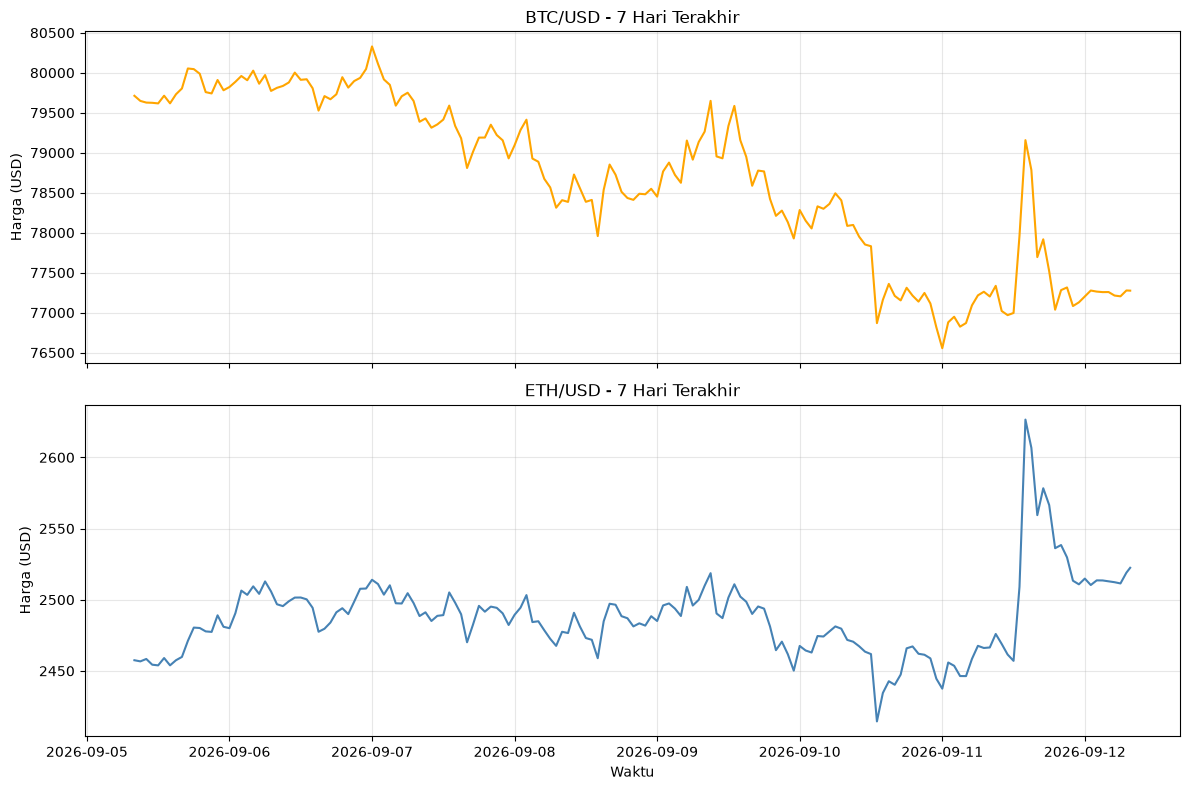

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_btc['timestamp'], df_btc['price'], color='orange')
axes[0].set_title('BTC/USD - 7 Hari Terakhir')
axes[0].set_ylabel('Harga (USD)')
axes[0].grid(alpha=0.3)

axes[1].plot(df_eth['timestamp'], df_eth['price'], color='steelblue')
axes[1].set_title('ETH/USD - 7 Hari Terakhir')
axes[1].set_ylabel('Harga (USD)')
axes[1].set_xlabel('Waktu')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Visualisasi volume perdagangan

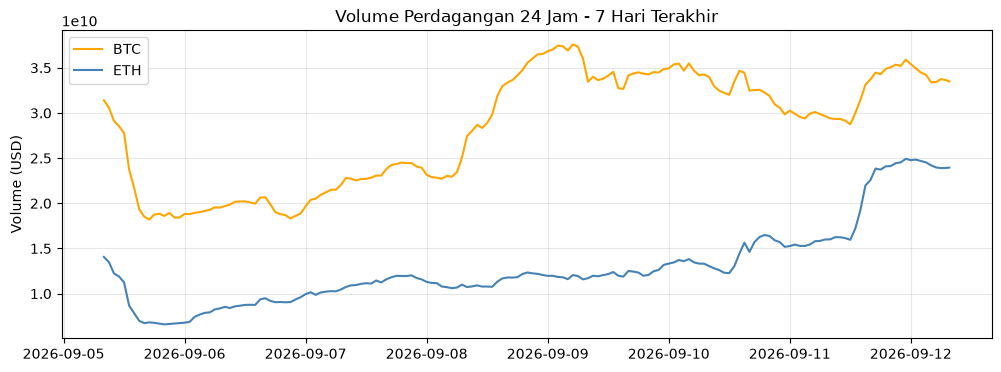

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_btc['timestamp'], df_btc['volume'], label='BTC', color='orange')
ax.plot(df_eth['timestamp'], df_eth['volume'], label='ETH', color='steelblue')
ax.set_title('Volume Perdagangan 24 Jam - 7 Hari Terakhir')
ax.set_ylabel('Volume (USD)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 6. Analisis volatilitas (bahan kalibrasi threshold label)

Menghitung persentase perubahan harga per jam

In [10]:
for name, df in [('BTC', df_btc), ('ETH', df_eth)]:
    df = df.sort_values('timestamp').copy()
    df['pct_change_1h'] = df['price'].pct_change() * 100

    print(f'=== {name}: distribusi perubahan harga per jam (%) ===')
    print(df['pct_change_1h'].describe())

    naik = (df['pct_change_1h'] > 0.5).mean() * 100
    turun = (df['pct_change_1h'] < -0.5).mean() * 100
    stabil = 100 - naik - turun
    print(f'Proporsi kelas dgn threshold \u00b10.5%: Naik={naik:.1f}%, Turun={turun:.1f}%, Stabil={stabil:.1f}%\n')

=== BTC: distribusi perubahan harga per jam (%) ===
count   168.00
mean     -0.02
std       0.33
min      -1.38
25%      -0.17
50%      -0.01
75%       0.14
max       1.53
Name: pct_change_1h, dtype: float64
Proporsi kelas dgn threshold ±0.5%: Naik=3.0%, Turun=4.7%, Stabil=92.3%

=== ETH: distribusi perubahan harga per jam (%) ===
count   168.00
mean      0.02
std       0.57
min      -1.92
25%      -0.23
50%      -0.03
75%       0.24
max       4.68
Name: pct_change_1h, dtype: float64
Proporsi kelas dgn threshold ±0.5%: Naik=8.9%, Turun=8.9%, Stabil=82.2%

